## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import data

In [2]:
survivors = pd.read_csv("survivors.csv")
survivors.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Descriptive stats

In [3]:
survivors.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Inspect data

In [4]:
survivors.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
survivors.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
survivors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
survivors.shape

(891, 12)

In [8]:
survivors.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Preliminary Correlation

In [9]:
corr = survivors.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

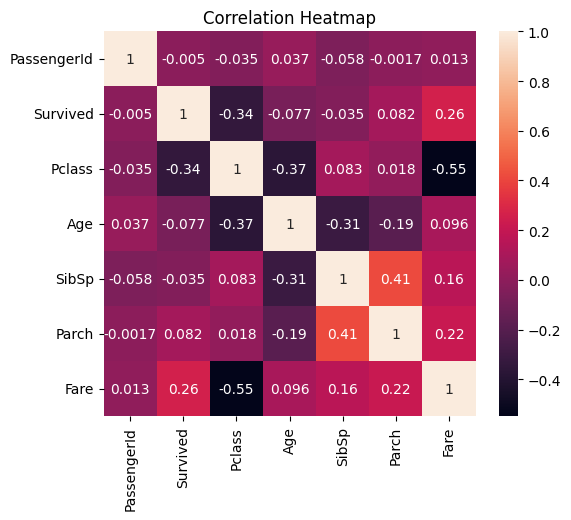

In [10]:
plt.figure(figsize=(6,5))
heat = sns.heatmap(data=corr, annot=True)
plt.title('Correlation Heatmap')

In [11]:
corr = survivors.apply(lambda x: x.factorize()[0]).corr()
corr

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,1.000000,-0.005007,0.018305,1.000000,-0.042939,0.120150,-0.031023,0.001206,0.760875,0.299982,0.241918,-0.030323
Survived,-0.005007,1.000000,0.247845,-0.005007,0.543351,0.042743,-0.136302,0.086210,-0.047298,0.191981,0.270495,0.101849
Pclass,0.018305,0.247845,1.000000,0.018305,0.118133,0.180735,-0.149630,-0.000343,0.020431,0.079498,0.187437,-0.168809
Name,1.000000,-0.005007,0.018305,1.000000,-0.042939,0.120150,-0.031023,0.001206,0.760875,0.299982,0.241918,-0.030323
Sex,-0.042939,0.543351,0.118133,-0.042939,1.000000,0.009117,-0.046152,0.242417,-0.132709,0.137725,0.082104,0.111249
Age,0.120150,0.042743,0.180735,0.120150,0.009117,1.000000,0.003777,0.136160,0.070385,0.114674,0.165159,-0.152716
SibSp,-0.031023,-0.136302,-0.149630,-0.031023,-0.046152,0.003777,1.000000,0.165255,-0.122426,-0.046556,-0.108709,-0.030612
Parch,0.001206,0.086210,-0.000343,0.001206,0.242417,0.136160,0.165255,1.000000,-0.262607,0.074306,-0.002761,-0.082982
Ticket,0.760875,-0.047298,0.020431,0.760875,-0.132709,0.070385,-0.122426,-0.262607,1.000000,0.303257,0.212438,-0.020135
Fare,0.299982,0.191981,0.079498,0.299982,0.137725,0.114674,-0.046556,0.074306,0.303257,1.000000,0.379659,0.077933


Text(0.5, 1.0, 'Correlation Heatmap')

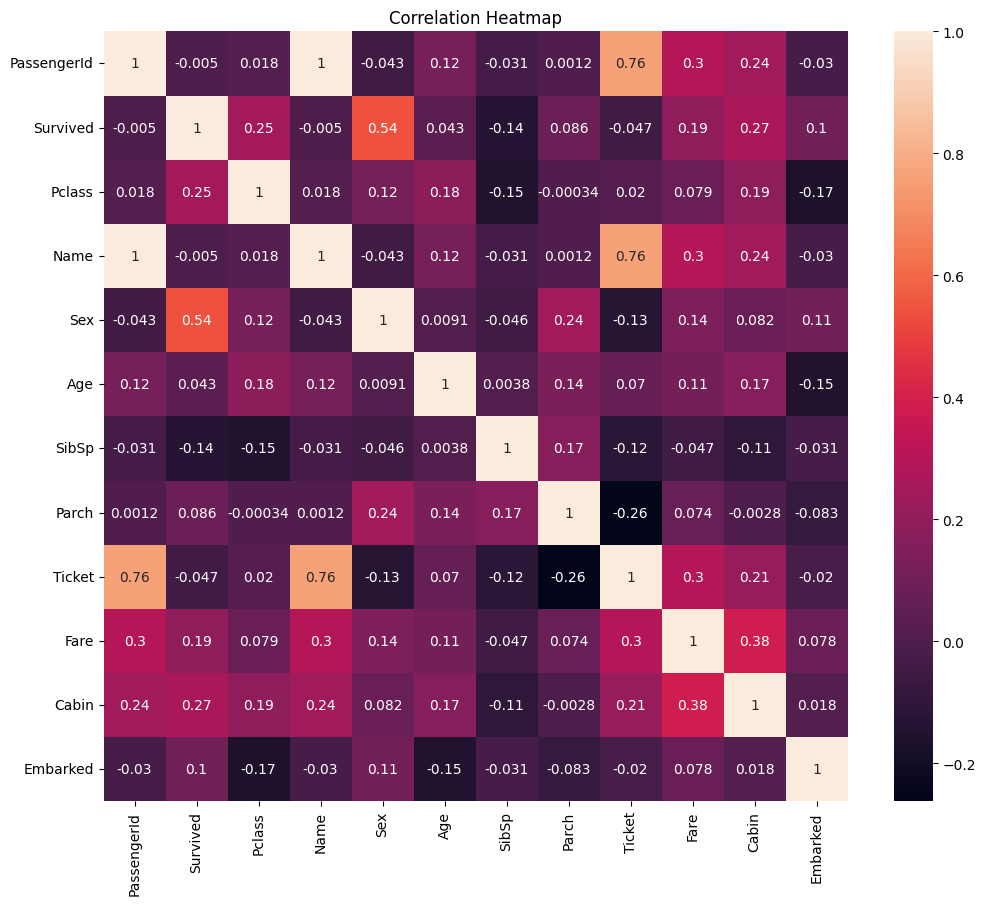

In [12]:
plt.figure(figsize=(12,10))
heat = sns.heatmap(data=corr, annot=True)
plt.title('Correlation Heatmap')

## Check for missing values

In [13]:
survivors.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Age and Pclass distributions

In [14]:
pAges = survivors['Age'].value_counts().sort_values()
pAges

Age
74.00     1
34.50     1
0.42      1
0.67      1
66.00     1
         ..
28.00    25
19.00    25
18.00    26
22.00    27
24.00    30
Name: count, Length: 88, dtype: int64

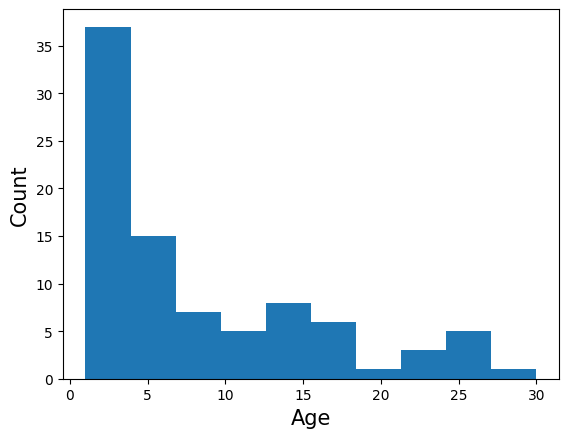

In [15]:
pAges.plot(kind='hist')
plt.xlabel('Age',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

In [16]:
pclass = survivors['Pclass'].value_counts().sort_values()
pclass

Pclass
2    184
1    216
3    491
Name: count, dtype: int64

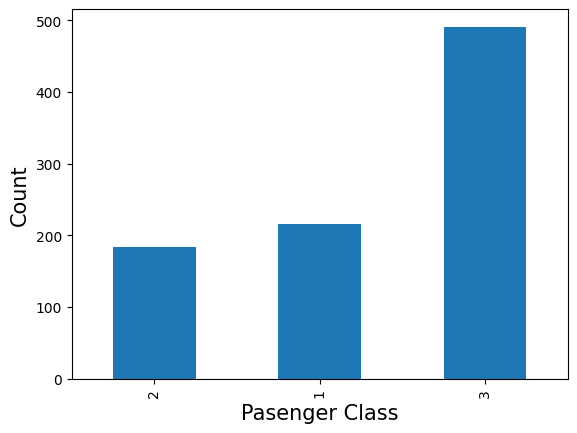

In [17]:
pclass.plot(kind='bar')
plt.xlabel('Pasenger Class',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

## Survival rates across Sex and Pclass

In [18]:
survival_count = survivors[['Sex', 'Pclass', 'Survived']].value_counts()
survival_count

Sex     Pclass  Survived
male    3       0           300
female  1       1            91
male    2       0            91
        1       0            77
female  3       0            72
                1            72
        2       1            70
male    3       1            47
        1       1            45
        2       1            17
female  2       0             6
        1       0             3
Name: count, dtype: int64

In [19]:
survival_rate = survivors[['Sex', 'Pclass', 'Survived']].groupby(['Sex', 'Pclass']).mean()
survival_rate

Survived
Sex    Pclass          
female 1       0.968085
       2       0.921053
       3       0.500000
male   1       0.368852
       2       0.157407
       3       0.135447

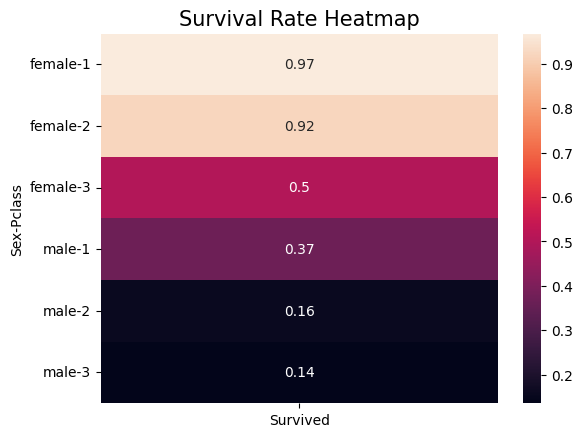

In [20]:
sns.heatmap(data=survival_rate, annot=True)
plt.title('Survival Rate Heatmap',fontsize=15)
plt.show()

## Scatter plot of Age vs. Fare coloured by survival

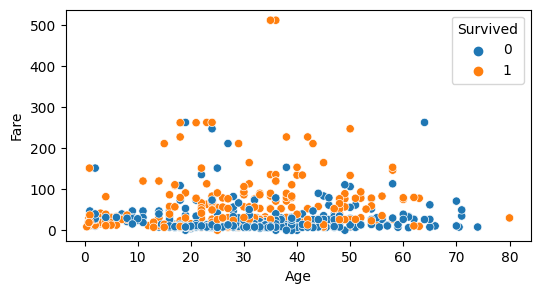

In [21]:
sns.scatterplot(data=survivors, x='Age', y='Fare', hue='Survived')
fig = plt.gcf()
fig.set_size_inches(6, 3)

## Sex survival rates

In [22]:
sex_survival_rate = survivors[['Sex', 'Survived']].groupby('Sex').mean()
sex_survival_rate

,Survived
Sex,
female,0.742038
male,0.188908


In [23]:
sex_survival_count = survivors[['Sex', 'Survived']].value_counts()
sex_survival_count

Sex     Survived
male    0           468
female  1           233
male    1           109
female  0            81
Name: count, dtype: int64

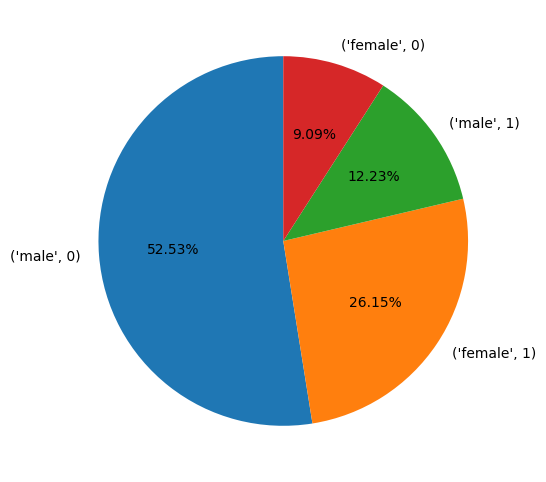

In [24]:
plt.pie(sex_survival_count.to_list(), labels = sex_survival_count.index, autopct = '%.2f%%', startangle=90)
fig = plt.gcf()
fig.set_size_inches(6, 6)

## Pasenger class survival rates

In [25]:
pclass_survival_rate = survivors[['Pclass', 'Survived']].groupby('Pclass').mean()
pclass_survival_rate

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [26]:
pclass_survival_count = survivors[['Pclass', 'Survived']].value_counts()
pclass_survival_count

Pclass  Survived
3       0           372
1       1           136
3       1           119
2       0            97
        1            87
1       0            80
Name: count, dtype: int64

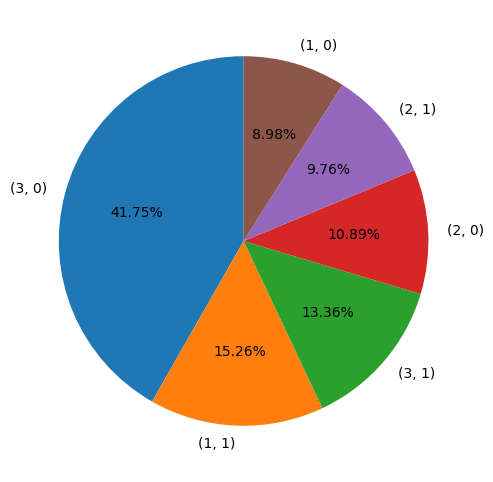

In [27]:
plt.pie(pclass_survival_count.to_list(), labels = pclass_survival_count.index, autopct = '%.2f%%', startangle=90)
fig = plt.gcf()
fig.set_size_inches(6, 6)

## Add Title feature

In [28]:
survivors

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [29]:
survivors['Title'] = survivors['Name'].str.split(', ').str[1].str.split().str[0]
survivors.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr.
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr.
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master.
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs.
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs.


## Add Family Members feature

In [30]:
survivors['Family_Members'] = survivors['SibSp'] + survivors['Parch'] + 1
survivors.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_Members
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.,1
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr.,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr.,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master.,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs.,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs.,2


## Check for missing values

In [31]:
survivors.isnull().sum()

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age               177
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
Title               0
Family_Members      0
dtype: int64

In [32]:
# Drop only the rows that contain null values in column 'Embarked' because there is only a small number of missing values.
survivors.dropna(subset=['Embarked'], inplace=True)

# Drop feature "Cabin" because there is a huge number of missing values.
survivors.drop('Cabin', inplace=True, axis=1)

survivors.isnull().sum()

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age               177
SibSp               0
Parch               0
Ticket              0
Fare                0
Embarked            0
Title               0
Family_Members      0
dtype: int64

In [33]:
# Fill the missing 'Age' values with the median of the other passengers' ages.
survivors['Age'] = survivors['Age'].fillna(survivors['Age'].median())
survivors.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Embarked          0
Title             0
Family_Members    0
dtype: int64

## Drop columns PassengerId, Name and Ticket because they only provide identification information

In [34]:
survivors.drop(['PassengerId', 'Name', 'Ticket'], inplace=True, axis=1)
survivors.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_Members
0,0,3,male,22.0,1,0,7.2500,S,Mr.,2
1,1,1,female,38.0,1,0,71.2833,C,Mrs.,2
2,1,3,female,26.0,0,0,7.9250,S,Miss.,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs.,2
4,0,3,male,35.0,0,0,8.0500,S,Mr.,1
5,0,3,male,28.0,0,0,8.4583,Q,Mr.,1
6,0,1,male,54.0,0,0,51.8625,S,Mr.,1
7,0,3,male,2.0,3,1,21.0750,S,Master.,5
8,1,3,female,27.0,0,2,11.1333,S,Mrs.,3
9,1,2,female,14.0,1,0,30.0708,C,Mrs.,2


## Check for outliers

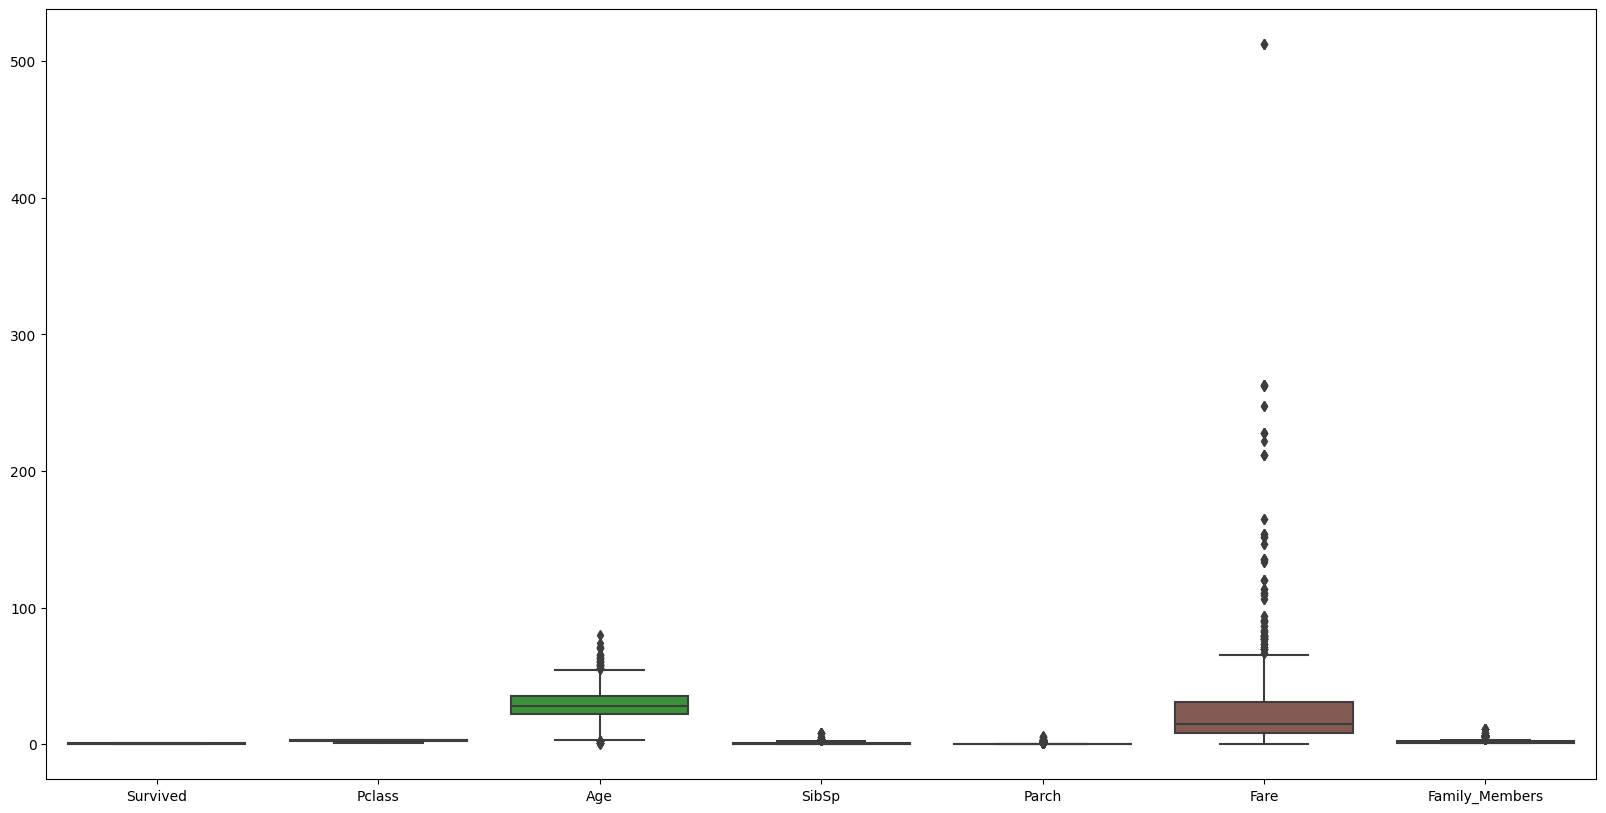

In [35]:
plt.figure(figsize=(20,10))
sns.boxplot(data=survivors)
plt.show()

### The boxplot shows several outliers. However, I decided not to remove any outliers because the values are a true reflection of the ticket prices.

## Converting text to numerical values

In [36]:
print('Sex:', survivors['Sex'].unique())
print('Embarked:', survivors['Embarked'].unique())
print('Title:', survivors['Title'].unique())

Sex: ['male' 'female']
Embarked: ['S' 'C' 'Q']
Title: ['Mr.' 'Mrs.' 'Miss.' 'Master.' 'Don.' 'Rev.' 'Dr.' 'Mme.' 'Ms.' 'Major.'
 'Lady.' 'Sir.' 'Mlle.' 'Col.' 'Capt.' 'the' 'Jonkheer.']


In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
survivors[['Sex', 'Embarked']] = survivors[['Sex', 'Embarked']].apply(label_encoder.fit_transform)
survivors.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_Members
0,0,3,1,22.0,1,0,7.2500,2,Mr.,2
1,1,1,0,38.0,1,0,71.2833,0,Mrs.,2
2,1,3,0,26.0,0,0,7.9250,2,Miss.,1
3,1,1,0,35.0,1,0,53.1000,2,Mrs.,2
4,0,3,1,35.0,0,0,8.0500,2,Mr.,1
5,0,3,1,28.0,0,0,8.4583,1,Mr.,1
6,0,1,1,54.0,0,0,51.8625,2,Mr.,1
7,0,3,1,2.0,3,1,21.0750,2,Master.,5
8,1,3,0,27.0,0,2,11.1333,2,Mrs.,3
9,1,2,0,14.0,1,0,30.0708,0,Mrs.,2


In [38]:
survivors_vectors = pd.get_dummies(survivors['Title'], dtype=int)
survivors_clean = pd.concat([survivors, survivors_vectors], axis=1)
survivors_clean = survivors_clean.drop(['Title'], axis=1)
survivors_clean.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Members,Capt.,...,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the
0,0,3,1,22.0,1,0,7.2500,2,2,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,38.0,1,0,71.2833,0,2,0,...,0,0,0,0,0,1,0,0,0,0
2,1,3,0,26.0,0,0,7.9250,2,1,0,...,0,1,0,0,0,0,0,0,0,0
3,1,1,0,35.0,1,0,53.1000,2,2,0,...,0,0,0,0,0,1,0,0,0,0
4,0,3,1,35.0,0,0,8.0500,2,1,0,...,0,0,0,0,1,0,0,0,0,0
5,0,3,1,28.0,0,0,8.4583,1,1,0,...,0,0,0,0,1,0,0,0,0,0
6,0,1,1,54.0,0,0,51.8625,2,1,0,...,0,0,0,0,1,0,0,0,0,0
7,0,3,1,2.0,3,1,21.0750,2,5,0,...,1,0,0,0,0,0,0,0,0,0
8,1,3,0,27.0,0,2,11.1333,2,3,0,...,0,0,0,0,0,1,0,0,0,0
9,1,2,0,14.0,1,0,30.0708,0,2,0,...,0,0,0,0,0,1,0,0,0,0


## Make sure the data is on the same scale

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
survivors_clean[['Age', 'Fare']] = pd.DataFrame(scaler.fit_transform(survivors_clean[['Age', 'Fare']]), columns = ['Age', 'Fare'])
survivors_clean.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Members,Capt.,...,Master.,Miss.,Mlle.,Mme.,Mr.,Mrs.,Ms.,Rev.,Sir.,the
0,0,3,1,0.271174,1,0,0.014151,2,2,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0.472229,1,0,0.139136,0,2,0,...,0,0,0,0,0,1,0,0,0,0
2,1,3,0,0.321438,0,0,0.015469,2,1,0,...,0,1,0,0,0,0,0,0,0,0
3,1,1,0,0.434531,1,0,0.103644,2,2,0,...,0,0,0,0,0,1,0,0,0,0
4,0,3,1,0.434531,0,0,0.015713,2,1,0,...,0,0,0,0,1,0,0,0,0,0
5,0,3,1,0.346569,0,0,0.016510,1,1,0,...,0,0,0,0,1,0,0,0,0,0
6,0,1,1,0.673285,0,0,0.101229,2,1,0,...,0,0,0,0,1,0,0,0,0,0
7,0,3,1,0.019854,3,1,0.041136,2,5,0,...,1,0,0,0,0,0,0,0,0,0
8,1,3,0,0.334004,0,2,0.021731,2,3,0,...,0,0,0,0,0,1,0,0,0,0
9,1,2,0,0.170646,1,0,0.058694,0,2,0,...,0,0,0,0,0,1,0,0,0,0


## Check if all objects have been converted

In [40]:
#checking if there're any column with of type 'object'
np.sum(survivors_clean.dtypes == 'object')

0

## Write cleaned and pre-processed data to CSV file

In [41]:
survivors_clean.to_csv('clean_survivors.csv', index=False, encoding='utf-8')